In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

print("Imports Loaded!!!!")

Imports Loaded!!!!


SIM-HVQC vs NO SIM-HVQC

MNIST
SIM-HVQC     Accuracy: 97.57 ± 0.05%
SIM-HVQC     Loss:     0.1437 ± 0.0139
NO SIM-HVQC  Accuracy: 97.48 ± 0.18%
NO SIM-HVQC  Loss:     0.1638 ± 0.0054

Fashion-MNIST
SIM-HVQC     Accuracy: 87.98 ± 0.08%
SIM-HVQC     Loss:     0.3345 ± 0.0132
NO SIM-HVQC  Accuracy: 87.51 ± 0.11%
NO SIM-HVQC  Loss:     0.4424 ± 0.0218

EMNIST
SIM-HVQC     Accuracy: 80.16 ± 0.17%
SIM-HVQC     Loss:     0.7212 ± 0.0236
NO SIM-HVQC  Accuracy: 78.99 ± 0.06%
NO SIM-HVQC  Loss:     0.8921 ± 0.0302

KMNIST
SIM-HVQC     Accuracy: 88.20 ± 0.63%
SIM-HVQC     Loss:     0.3544 ± 0.0283
NO SIM-HVQC  Accuracy: 88.23 ± 0.57%
NO SIM-HVQC  Loss:     0.9284 ± 0.0593


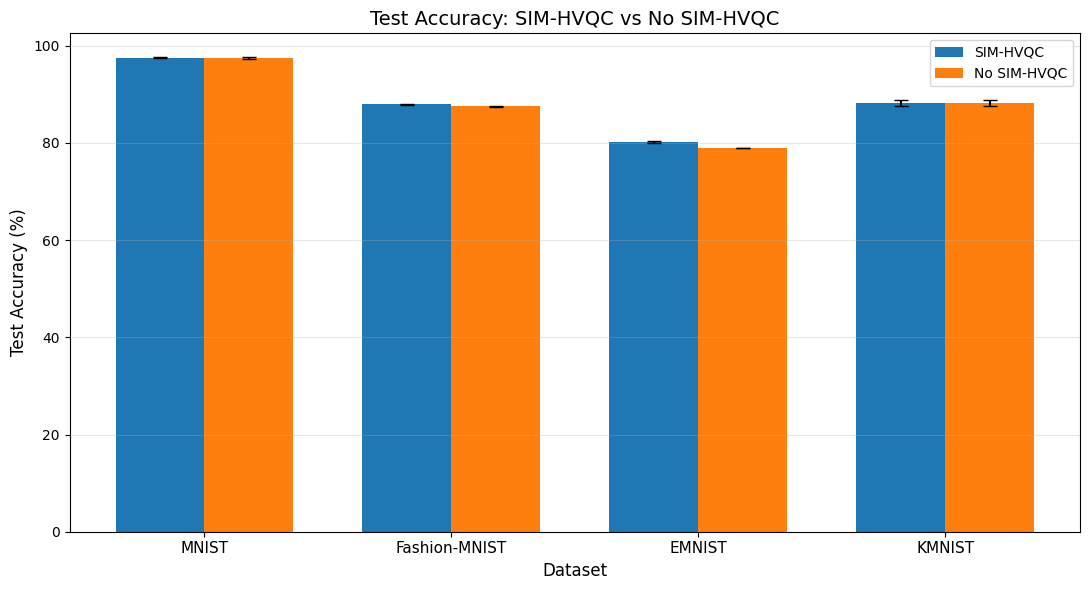

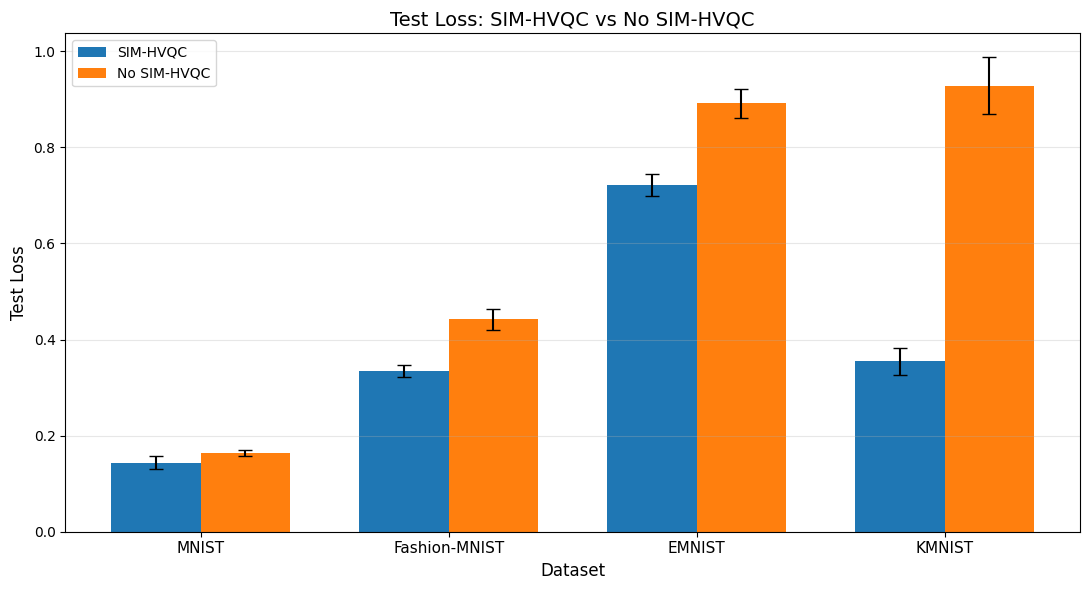

In [3]:
# ============================================================
# RESULTS
# ============================================================

datasets = ["MNIST", "Fashion-MNIST", "EMNIST", "KMNIST"]

# ------------------------------------------------------------
# SIM-HVQC results
# Format: (Accuracy %, Loss)
# ------------------------------------------------------------

sim_hvqc = {
    "MNIST": [
        (97.52, 0.1377),
        (97.63, 0.1599),
        (97.63, 0.1599),
        (97.54, 0.1456),
        (97.54, 0.1305),
        (97.55, 0.1287),
    ],

    "Fashion-MNIST": [
        (88.01, 0.3441),
        (87.93, 0.3271),
        (88.01, 0.3545),
        (88.12, 0.3183),
        (87.90, 0.3361),
        (87.93, 0.3271),
    ],

    "EMNIST": [
        (80.06, 0.7100),
        (80.02, 0.6871),
        (80.41, 0.7262),
        (80.05, 0.7483),
        (80.26, 0.7345),
    ],

    "KMNIST": [
        (89.12, 0.3231),
        (87.21, 0.3970),
        (88.44, 0.3576),
        (88.39, 0.3260),
        (88.05, 0.3736),
        (88.00, 0.3494),
    ]
}


# ------------------------------------------------------------
# NO SIM-HVQC results
# Format: (Accuracy %, Loss)
# ------------------------------------------------------------

no_sim_hvqc = {
    "MNIST": [
        (97.61, 0.1599),
        (97.35, 0.1676),
    ],

    "Fashion-MNIST": [
        (87.43, 0.4578),
        (87.59, 0.4270),
    ],

    "EMNIST": [
        (78.95, 0.9135),
        (79.03, 0.8708),
    ],

    "KMNIST": [
        (88.63, 0.9704),
        (87.83, 0.8865),
    ]
}


# ============================================================
# CALCULATE MEAN AND STANDARD DEVIATION
# ============================================================

sim_acc_mean = []
sim_acc_std = []
sim_loss_mean = []
sim_loss_std = []

no_sim_acc_mean = []
no_sim_acc_std = []
no_sim_loss_mean = []
no_sim_loss_std = []

for dataset in datasets:

    # SIM-HVQC
    sim_acc = [x[0] for x in sim_hvqc[dataset]]
    sim_loss = [x[1] for x in sim_hvqc[dataset]]

    sim_acc_mean.append(np.mean(sim_acc))
    sim_acc_std.append(np.std(sim_acc, ddof=1))

    sim_loss_mean.append(np.mean(sim_loss))
    sim_loss_std.append(np.std(sim_loss, ddof=1))

    # NO SIM-HVQC
    no_acc = [x[0] for x in no_sim_hvqc[dataset]]
    no_loss = [x[1] for x in no_sim_hvqc[dataset]]

    no_sim_acc_mean.append(np.mean(no_acc))
    no_sim_acc_std.append(np.std(no_acc, ddof=1))

    no_sim_loss_mean.append(np.mean(no_loss))
    no_sim_loss_std.append(np.std(no_loss, ddof=1))


# ============================================================
# PRINT NUMERICAL RESULTS
# ============================================================

print("=" * 75)
print("SIM-HVQC vs NO SIM-HVQC")
print("=" * 75)

for i, dataset in enumerate(datasets):

    print(f"\n{dataset}")

    print(
        f"SIM-HVQC     Accuracy: "
        f"{sim_acc_mean[i]:.2f} ± {sim_acc_std[i]:.2f}%"
    )

    print(
        f"SIM-HVQC     Loss:     "
        f"{sim_loss_mean[i]:.4f} ± {sim_loss_std[i]:.4f}"
    )

    print(
        f"NO SIM-HVQC  Accuracy: "
        f"{no_sim_acc_mean[i]:.2f} ± {no_sim_acc_std[i]:.2f}%"
    )

    print(
        f"NO SIM-HVQC  Loss:     "
        f"{no_sim_loss_mean[i]:.4f} ± {no_sim_loss_std[i]:.4f}"
    )


# ============================================================
# VISUALIZATION
# ============================================================

x = np.arange(len(datasets))
width = 0.36


# ------------------------------------------------------------
# 1. ACCURACY COMPARISON
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))

plt.bar(
    x - width / 2,
    sim_acc_mean,
    width,
    yerr=sim_acc_std,
    capsize=5,
    label="SIM-HVQC"
)

plt.bar(
    x + width / 2,
    no_sim_acc_mean,
    width,
    yerr=no_sim_acc_std,
    capsize=5,
    label="No SIM-HVQC"
)

plt.xticks(x, datasets, fontsize=11)
plt.ylabel("Test Accuracy (%)", fontsize=12)
plt.xlabel("Dataset", fontsize=12)
plt.title("Test Accuracy: SIM-HVQC vs No SIM-HVQC", fontsize=14)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. LOSS COMPARISON
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))

plt.bar(
    x - width / 2,
    sim_loss_mean,
    width,
    yerr=sim_loss_std,
    capsize=5,
    label="SIM-HVQC"
)

plt.bar(
    x + width / 2,
    no_sim_loss_mean,
    width,
    yerr=no_sim_loss_std,
    capsize=5,
    label="No SIM-HVQC"
)

plt.xticks(x, datasets, fontsize=11)
plt.ylabel("Test Loss", fontsize=12)
plt.xlabel("Dataset", fontsize=12)
plt.title("Test Loss: SIM-HVQC vs No SIM-HVQC", fontsize=14)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

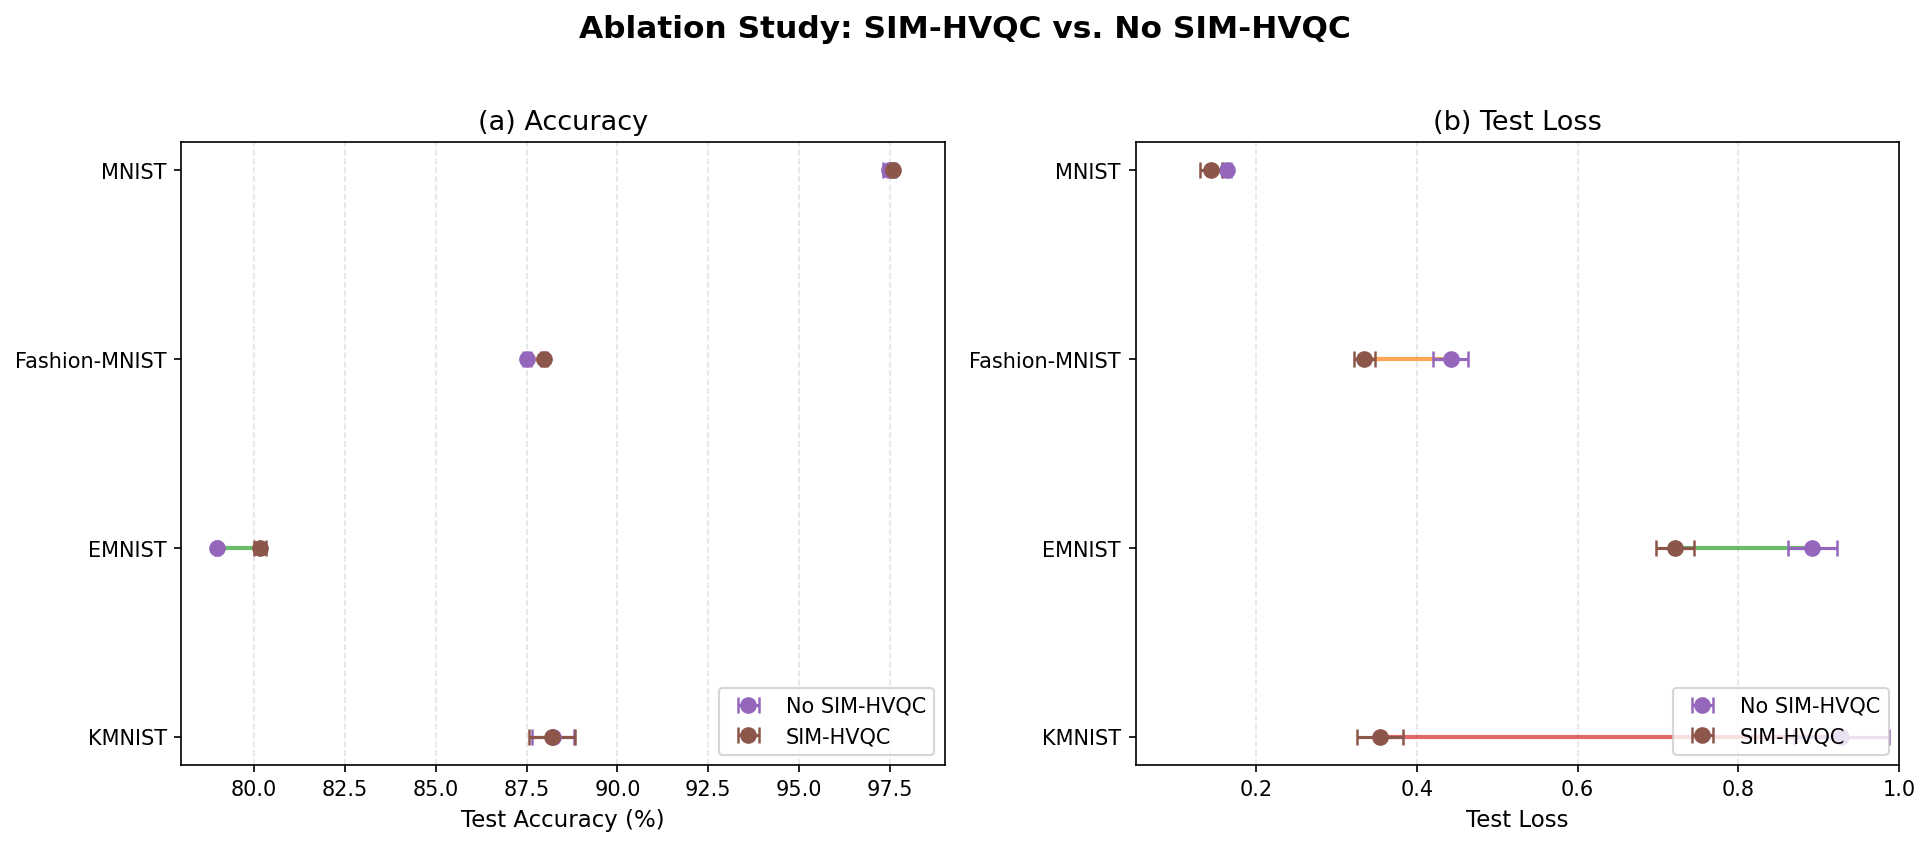

In [4]:
# ============================================================
# SIM-HVQC vs NO SIM-HVQC
# Publication-quality Dumbbell Plot with Error Bars
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Data
# ------------------------------------------------------------

datasets = ["MNIST", "Fashion-MNIST", "EMNIST", "KMNIST"]

# Accuracy (%)
acc_sim = np.array([97.57, 87.98, 80.16, 88.20])
acc_sim_std = np.array([0.05, 0.08, 0.17, 0.63])

acc_no = np.array([97.48, 87.51, 78.99, 88.23])
acc_no_std = np.array([0.18, 0.11, 0.06, 0.57])

# Loss
loss_sim = np.array([0.1437, 0.3345, 0.7212, 0.3544])
loss_sim_std = np.array([0.0139, 0.0132, 0.0236, 0.0283])

loss_no = np.array([0.1638, 0.4424, 0.8921, 0.9284])
loss_no_std = np.array([0.0054, 0.0218, 0.0302, 0.0593])


# ------------------------------------------------------------
# Plot settings
# ------------------------------------------------------------

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "font.family": "DejaVu Sans"
})

fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 5.5)
)

y = np.arange(len(datasets))

# ============================================================
# PANEL (a): ACCURACY
# ============================================================

ax = axes[0]

for i in range(len(datasets)):

    # Connecting line
    ax.plot(
        [acc_no[i], acc_sim[i]],
        [y[i], y[i]],
        linewidth=2,
        alpha=0.7
    )

# No SIM-HVQC
ax.errorbar(
    acc_no,
    y,
    xerr=acc_no_std,
    fmt="o",
    markersize=7,
    capsize=4,
    capthick=1.2,
    linewidth=1.5,
    label="No SIM-HVQC"
)

# SIM-HVQC
ax.errorbar(
    acc_sim,
    y,
    xerr=acc_sim_std,
    fmt="o",
    markersize=7,
    capsize=4,
    capthick=1.2,
    linewidth=1.5,
    label="SIM-HVQC"
)

ax.set_yticks(y)
ax.set_yticklabels(datasets)

ax.set_xlabel("Test Accuracy (%)")
ax.set_title("(a) Accuracy")

ax.set_xlim(78, 99)
ax.invert_yaxis()

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.35
)

ax.legend(
    loc="lower right",
    frameon=True
)


# ============================================================
# PANEL (b): LOSS
# ============================================================

ax = axes[1]

for i in range(len(datasets)):

    # Connecting line
    ax.plot(
        [loss_no[i], loss_sim[i]],
        [y[i], y[i]],
        linewidth=2,
        alpha=0.7
    )

# No SIM-HVQC
ax.errorbar(
    loss_no,
    y,
    xerr=loss_no_std,
    fmt="o",
    markersize=7,
    capsize=4,
    capthick=1.2,
    linewidth=1.5,
    label="No SIM-HVQC"
)

# SIM-HVQC
ax.errorbar(
    loss_sim,
    y,
    xerr=loss_sim_std,
    fmt="o",
    markersize=7,
    capsize=4,
    capthick=1.2,
    linewidth=1.5,
    label="SIM-HVQC"
)

ax.set_yticks(y)
ax.set_yticklabels(datasets)

ax.set_xlabel("Test Loss")
ax.set_title("(b) Test Loss")

ax.set_xlim(0.05, 1.0)
ax.invert_yaxis()

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.35
)

ax.legend(
    loc="lower right",
    frameon=True
)


# ============================================================
# Overall formatting
# ============================================================

fig.suptitle(
    "Ablation Study: SIM-HVQC vs. No SIM-HVQC",
    fontsize=15,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

# ------------------------------------------------------------
# Save high-resolution versions
# ------------------------------------------------------------

plt.savefig(
    "/kaggle/working/sim_hvqc_dumbbell.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "/kaggle/working/sim_hvqc_dumbbell.pdf",
    bbox_inches="tight"
)

plt.show()

SIM-HVQC ABLATION RESULTS
Dataset                Δ Accuracy         Loss Δ    Loss Reduction
--------------------------------------------------------------------------------
MNIST                    +0.09 pp         0.0201          12.27%
Fashion-MNIST            +0.47 pp         0.1079          24.39%
EMNIST                   +1.17 pp         0.1709          19.16%
KMNIST                   -0.03 pp         0.5740          61.83%


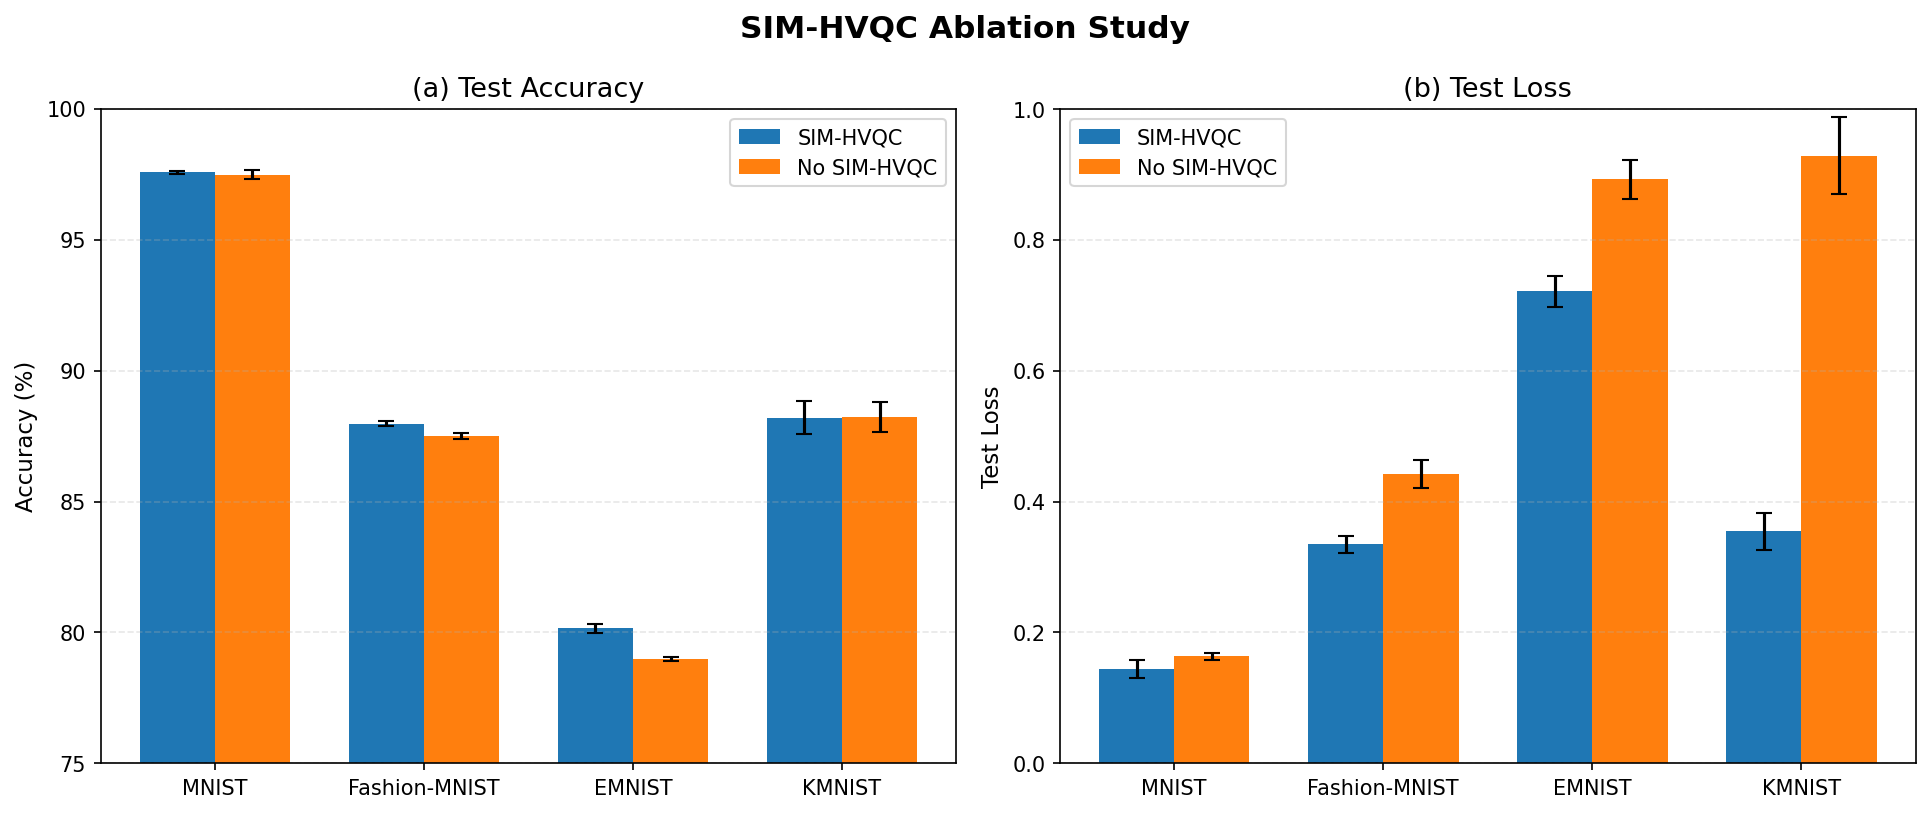

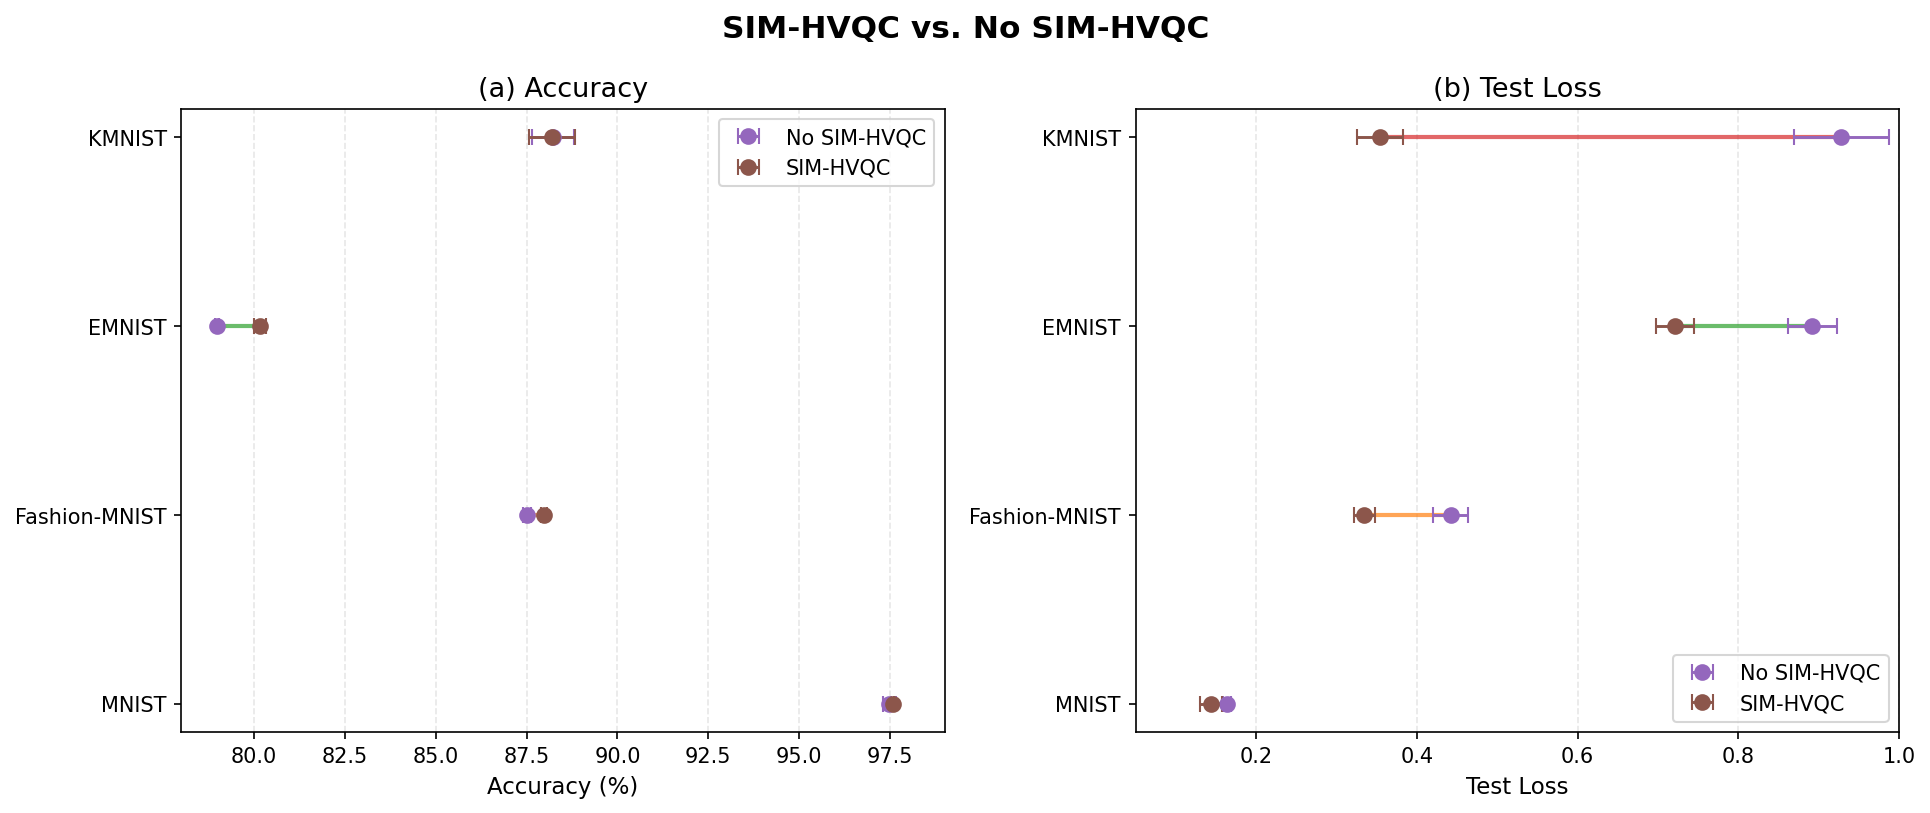

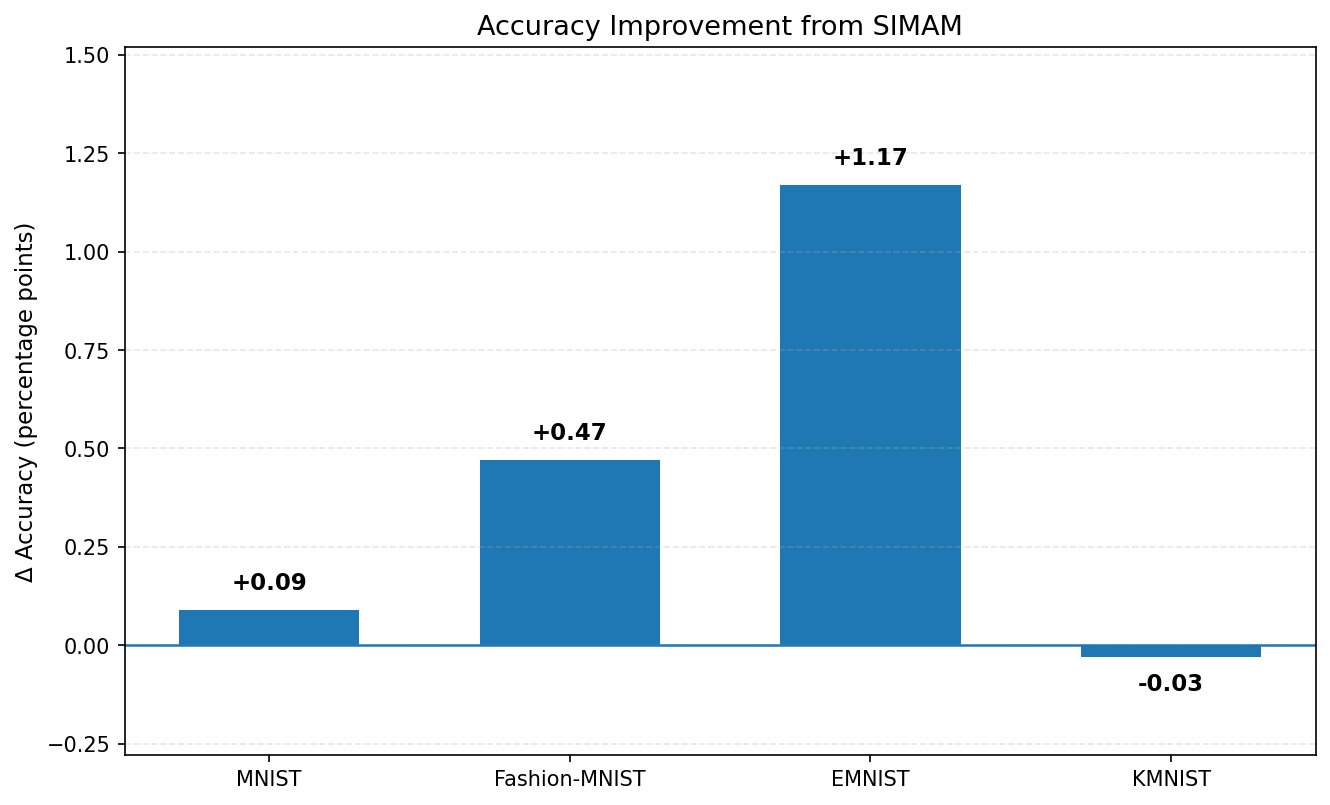

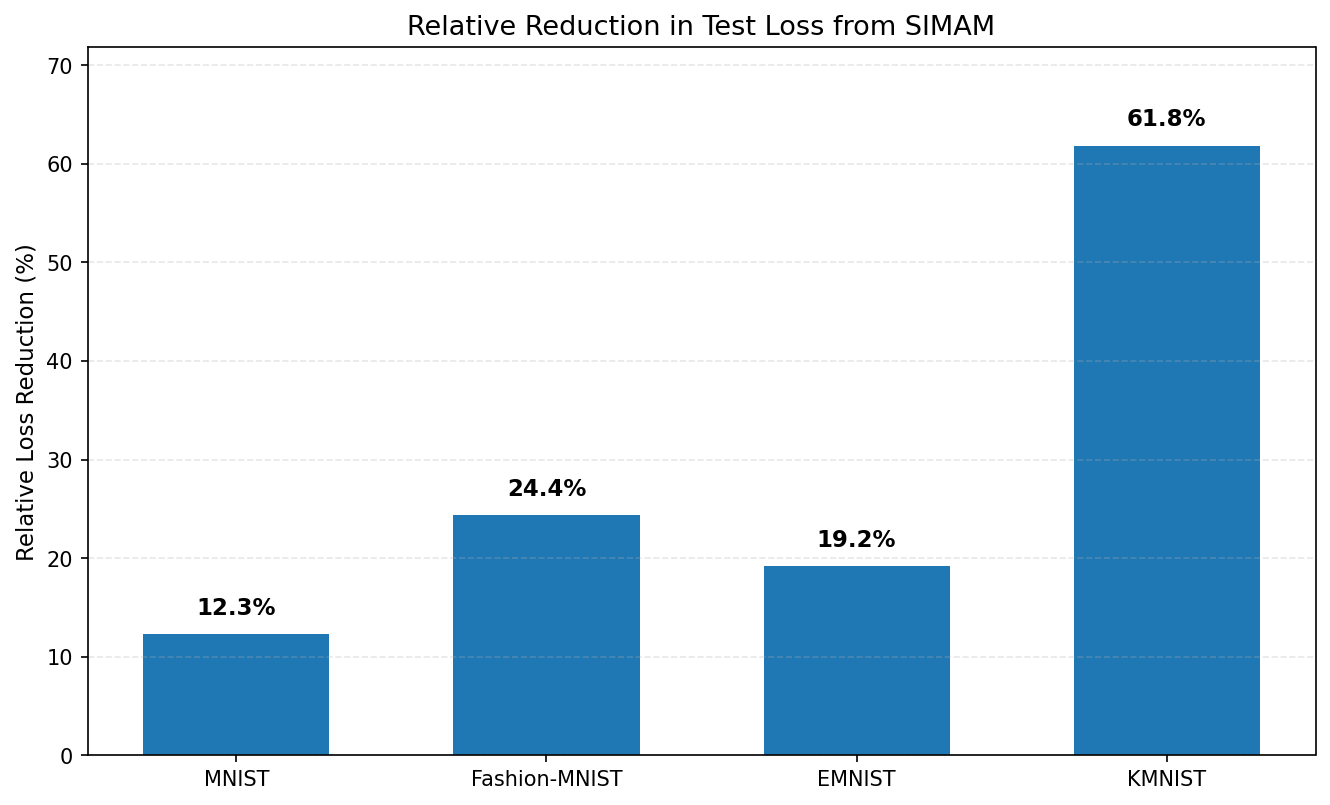

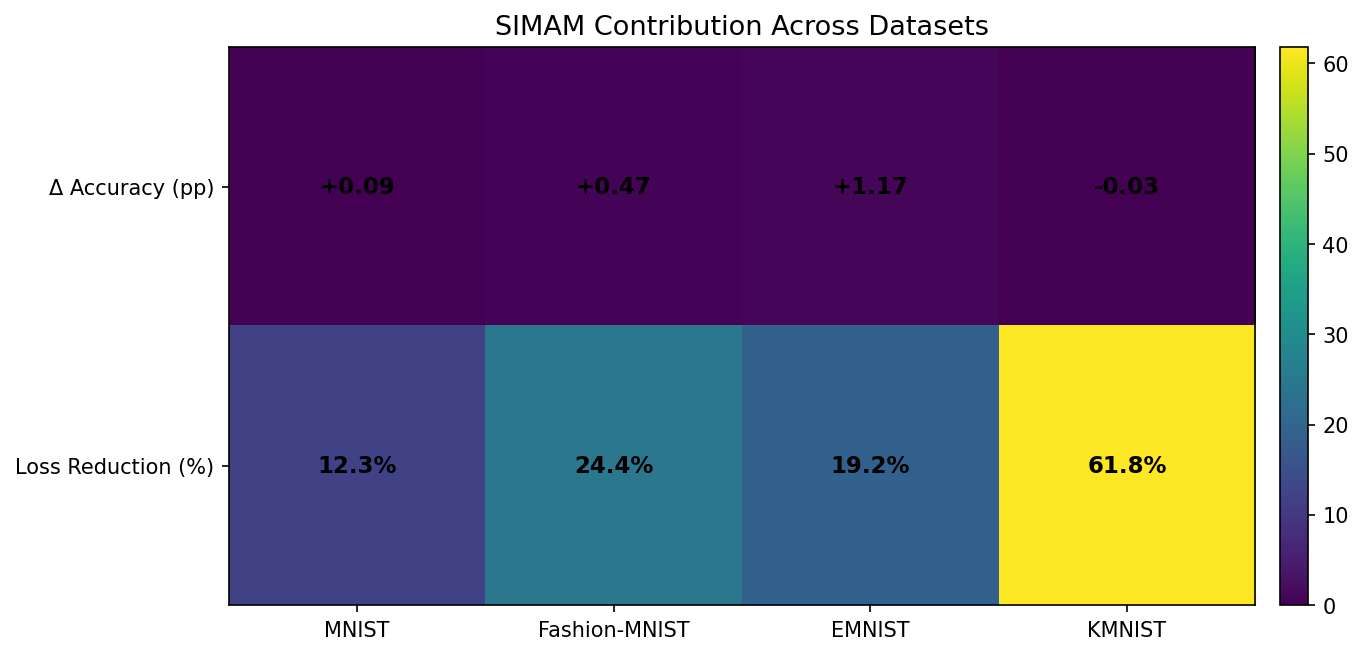

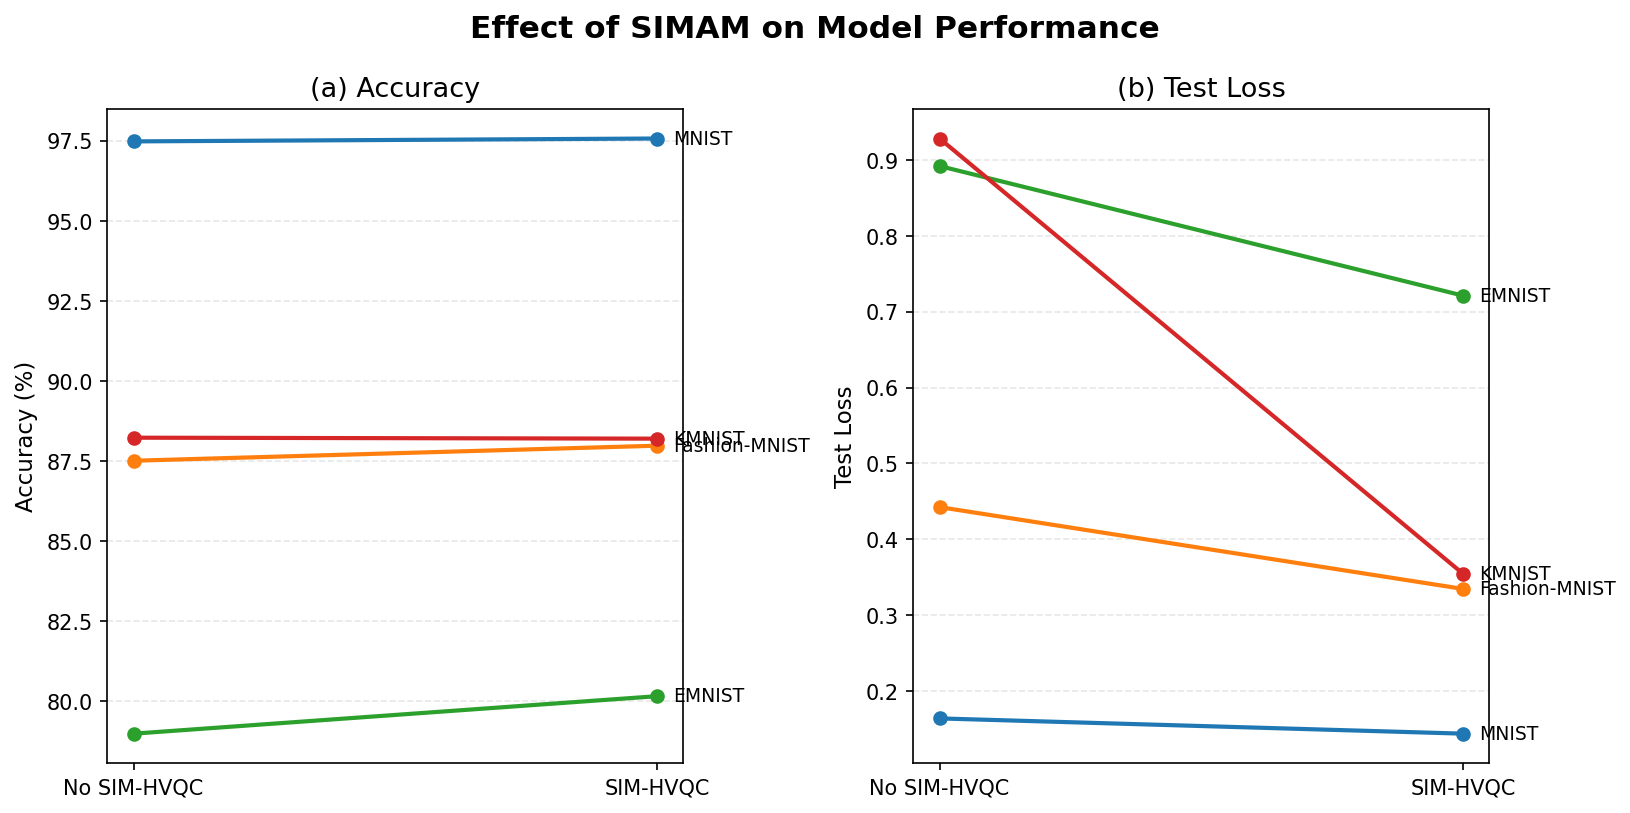

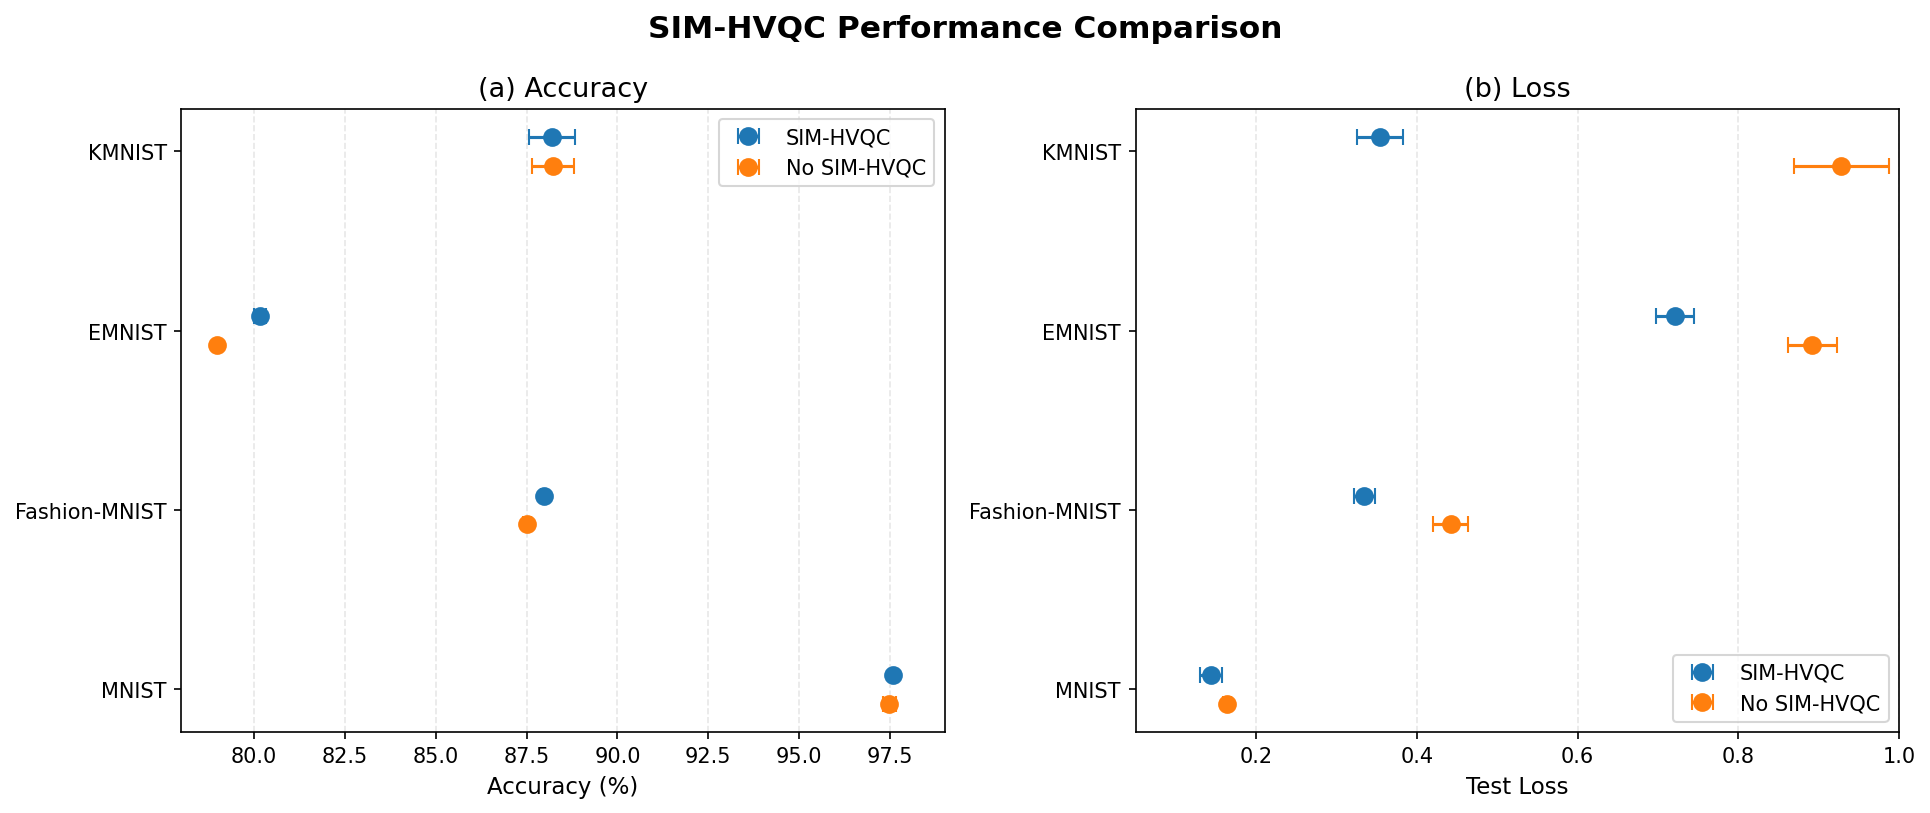

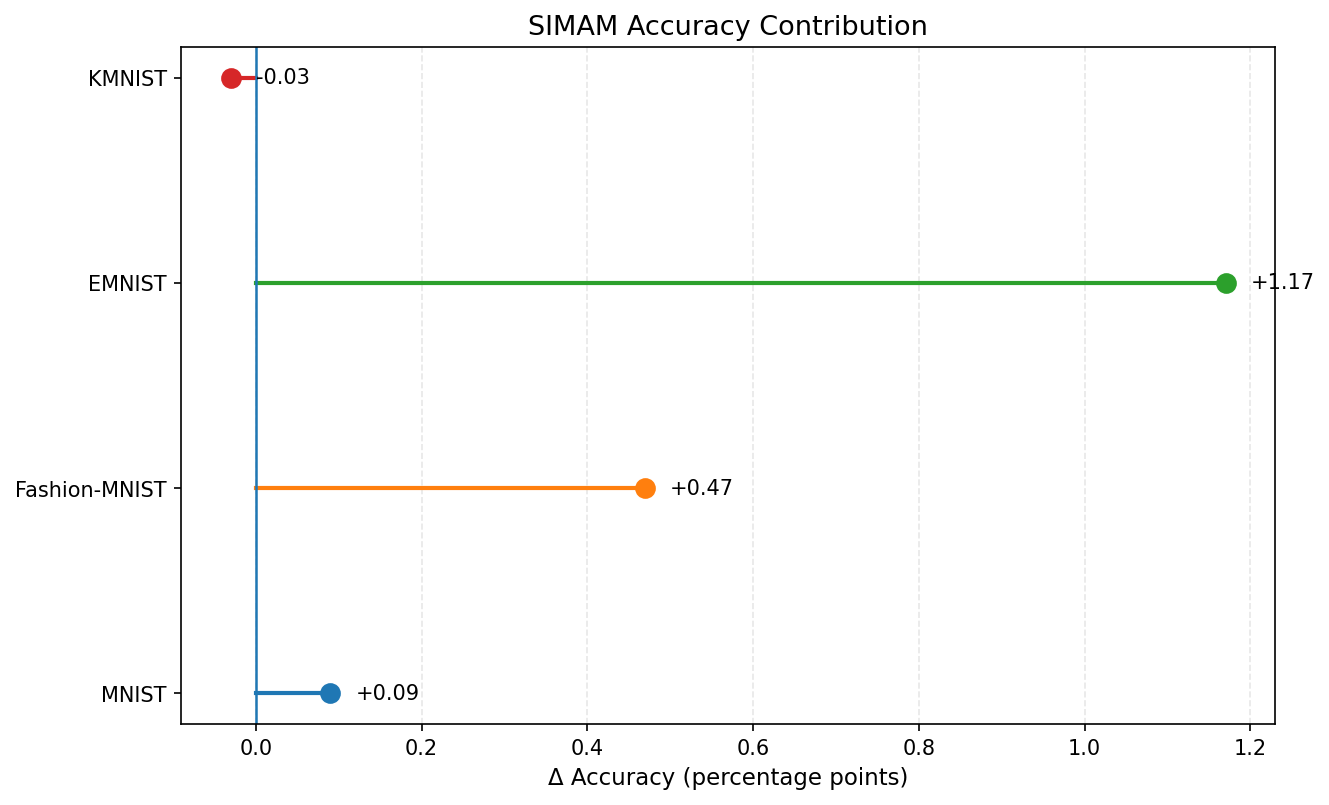

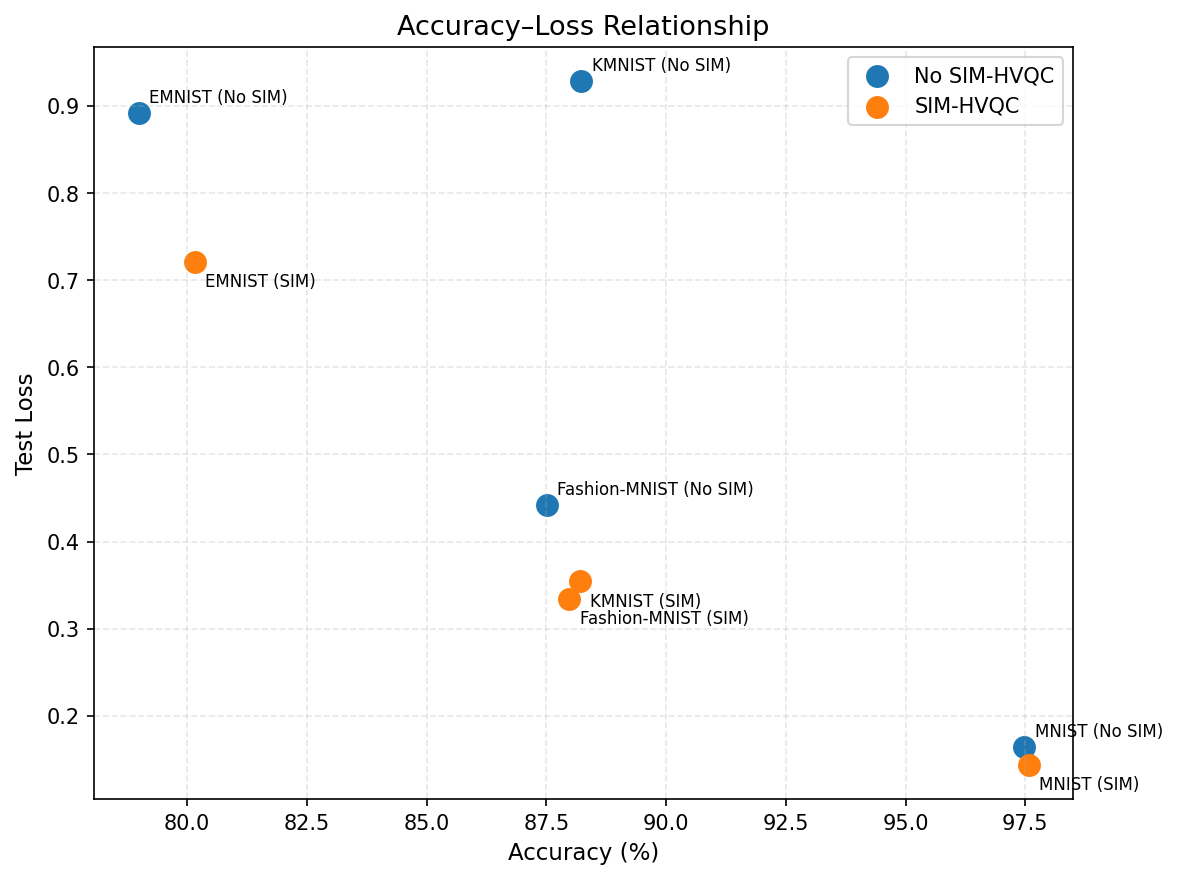

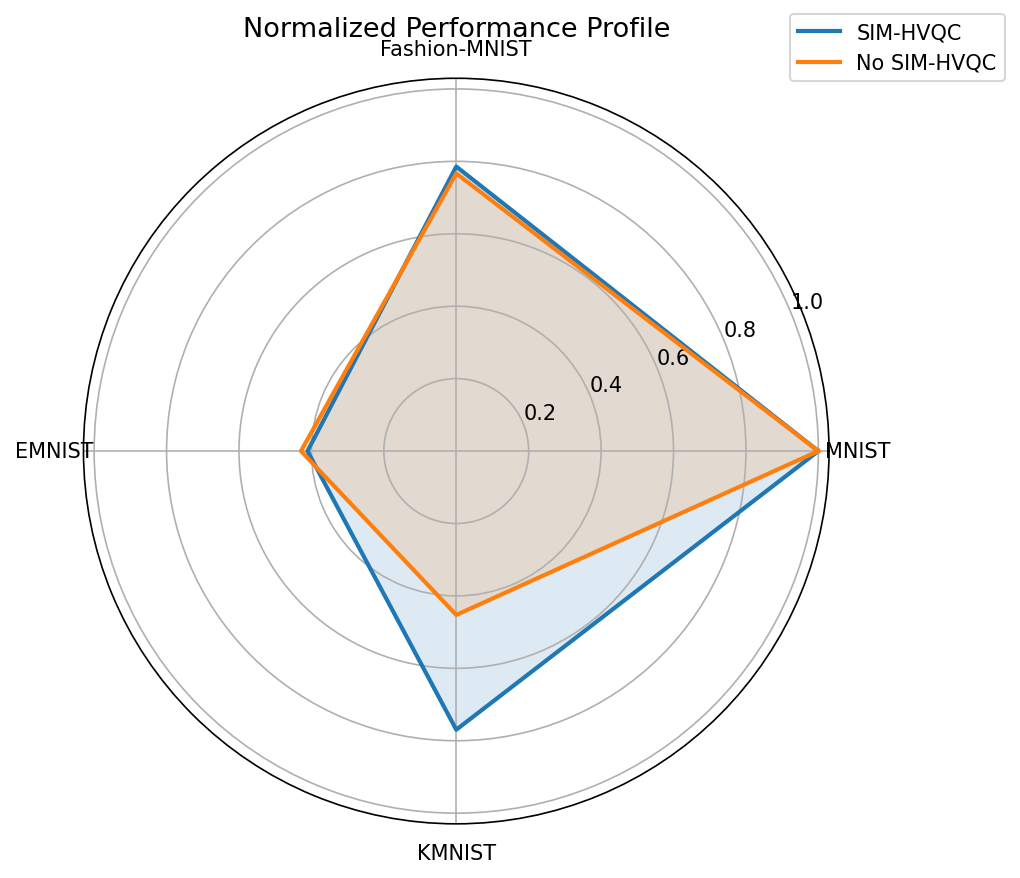


Generated figures:
01_grouped_bar
02_dumbbell
03_delta_accuracy
04_loss_reduction
05_heatmap
06_slope
07_dot_plot
08_lollipop
09_accuracy_loss_scatter
10_radar

Files saved in:
/kaggle/working/


In [6]:
# ============================================================
# SIM-HVQC ABLATION VISUALIZATION
# SIM-HVQC vs NO SIM-HVQC
#
# Generates:
# 1. Grouped Bar Plot + Error Bars
# 2. Dumbbell Plot + Error Bars
# 3. Delta / Improvement Plot
# 4. Relative Loss Reduction Plot
# 5. Heatmap
# 6. Slope Chart
# 7. Dot Plot
# 8. Lollipop Plot
# 9. Accuracy vs Loss Scatter
# 10. Radar Chart
#
# All figures saved at 600 DPI
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ============================================================
# GLOBAL SETTINGS
# ============================================================

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.dpi": 150,
    "savefig.dpi": 600
})

# ============================================================
# DATA
# ============================================================

datasets = np.array([
    "MNIST",
    "Fashion-MNIST",
    "EMNIST",
    "KMNIST"
])

# ----------------------------
# Accuracy
# ----------------------------

acc_sim = np.array([
    97.57,
    87.98,
    80.16,
    88.20
])

acc_sim_std = np.array([
    0.05,
    0.08,
    0.17,
    0.63
])

acc_no = np.array([
    97.48,
    87.51,
    78.99,
    88.23
])

acc_no_std = np.array([
    0.18,
    0.11,
    0.06,
    0.57
])

# ----------------------------
# Loss
# ----------------------------

loss_sim = np.array([
    0.1437,
    0.3345,
    0.7212,
    0.3544
])

loss_sim_std = np.array([
    0.0139,
    0.0132,
    0.0236,
    0.0283
])

loss_no = np.array([
    0.1638,
    0.4424,
    0.8921,
    0.9284
])

loss_no_std = np.array([
    0.0054,
    0.0218,
    0.0302,
    0.0593
])


# ============================================================
# CALCULATED METRICS
# ============================================================

# Accuracy improvement
delta_acc = acc_sim - acc_no

# Absolute loss reduction
delta_loss = loss_no - loss_sim

# Relative loss reduction
loss_reduction = (
    (loss_no - loss_sim) / loss_no
) * 100

# Relative accuracy improvement
relative_acc = (
    (acc_sim - acc_no) / acc_no
) * 100


# ============================================================
# PRINT RESULTS
# ============================================================

print("=" * 80)
print("SIM-HVQC ABLATION RESULTS")
print("=" * 80)

print(
    f"{'Dataset':<18}"
    f"{'Δ Accuracy':>15}"
    f"{'Loss Δ':>15}"
    f"{'Loss Reduction':>18}"
)

print("-" * 80)

for i in range(len(datasets)):
    print(
        f"{datasets[i]:<18}"
        f"{delta_acc[i]:>+12.2f} pp"
        f"{delta_loss[i]:>15.4f}"
        f"{loss_reduction[i]:>15.2f}%"
    )

print("=" * 80)


# ============================================================
# 1. GROUPED BAR PLOT + ERROR BARS
# ============================================================

x = np.arange(len(datasets))
width = 0.36

fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 5.5)
)

# ----------------------------
# Accuracy
# ----------------------------

ax = axes[0]

ax.bar(
    x - width / 2,
    acc_sim,
    width,
    yerr=acc_sim_std,
    capsize=4,
    label="SIM-HVQC"
)

ax.bar(
    x + width / 2,
    acc_no,
    width,
    yerr=acc_no_std,
    capsize=4,
    label="No SIM-HVQC"
)

ax.set_xticks(x)
ax.set_xticklabels(datasets)

ax.set_ylabel("Accuracy (%)")
ax.set_title("(a) Test Accuracy")

ax.set_ylim(75, 100)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend()


# ----------------------------
# Loss
# ----------------------------

ax = axes[1]

ax.bar(
    x - width / 2,
    loss_sim,
    width,
    yerr=loss_sim_std,
    capsize=4,
    label="SIM-HVQC"
)

ax.bar(
    x + width / 2,
    loss_no,
    width,
    yerr=loss_no_std,
    capsize=4,
    label="No SIM-HVQC"
)

ax.set_xticks(x)
ax.set_xticklabels(datasets)

ax.set_ylabel("Test Loss")
ax.set_title("(b) Test Loss")

ax.set_ylim(0, 1.0)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend()

fig.suptitle(
    "SIM-HVQC Ablation Study",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/01_grouped_bar.png",
    bbox_inches="tight"
)

plt.savefig(
    "/kaggle/working/01_grouped_bar.pdf",
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 2. DUMBBELL PLOT + ERROR BARS
# ============================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 5.5)
)

y = np.arange(len(datasets))

# ----------------------------
# Accuracy Dumbbell
# ----------------------------

ax = axes[0]

for i in range(len(datasets)):

    ax.plot(
        [acc_no[i], acc_sim[i]],
        [y[i], y[i]],
        linewidth=2,
        alpha=0.7
    )

ax.errorbar(
    acc_no,
    y,
    xerr=acc_no_std,
    fmt="o",
    markersize=7,
    capsize=4,
    linewidth=1.4,
    label="No SIM-HVQC"
)

ax.errorbar(
    acc_sim,
    y,
    xerr=acc_sim_std,
    fmt="o",
    markersize=7,
    capsize=4,
    linewidth=1.4,
    label="SIM-HVQC"
)

ax.set_yticks(y)
ax.set_yticklabels(datasets)

ax.set_xlabel("Accuracy (%)")
ax.set_title("(a) Accuracy")

ax.set_xlim(78, 99)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

ax.legend()

# ----------------------------
# Loss Dumbbell
# ----------------------------

ax = axes[1]

for i in range(len(datasets)):

    ax.plot(
        [loss_no[i], loss_sim[i]],
        [y[i], y[i]],
        linewidth=2,
        alpha=0.7
    )

ax.errorbar(
    loss_no,
    y,
    xerr=loss_no_std,
    fmt="o",
    markersize=7,
    capsize=4,
    linewidth=1.4,
    label="No SIM-HVQC"
)

ax.errorbar(
    loss_sim,
    y,
    xerr=loss_sim_std,
    fmt="o",
    markersize=7,
    capsize=4,
    linewidth=1.4,
    label="SIM-HVQC"
)

ax.set_yticks(y)
ax.set_yticklabels(datasets)

ax.set_xlabel("Test Loss")
ax.set_title("(b) Test Loss")

ax.set_xlim(0.05, 1.0)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

ax.legend()

fig.suptitle(
    "SIM-HVQC vs. No SIM-HVQC",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/02_dumbbell.png",
    bbox_inches="tight"
)

plt.savefig(
    "/kaggle/working/02_dumbbell.pdf",
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 3. DELTA / IMPROVEMENT PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 5.5)
)

bars = ax.bar(
    datasets,
    delta_acc,
    width=0.6
)

ax.axhline(
    0,
    linewidth=1.2
)

ax.set_ylabel(
    "Δ Accuracy (percentage points)"
)

ax.set_title(
    "Accuracy Improvement from SIMAM"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

for bar, value in zip(bars, delta_acc):

    if value >= 0:
        ypos = value + 0.04
        va = "bottom"
    else:
        ypos = value - 0.04
        va = "top"

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        ypos,
        f"{value:+.2f}",
        ha="center",
        va=va,
        fontweight="bold"
    )

ax.set_ylim(
    min(delta_acc) - 0.25,
    max(delta_acc) + 0.35
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/03_delta_accuracy.png",
    bbox_inches="tight"
)

plt.savefig(
    "/kaggle/working/03_delta_accuracy.pdf",
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 4. RELATIVE LOSS REDUCTION
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 5.5)
)

bars = ax.bar(
    datasets,
    loss_reduction,
    width=0.6
)

ax.set_ylabel(
    "Relative Loss Reduction (%)"
)

ax.set_title(
    "Relative Reduction in Test Loss from SIMAM"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

for bar, value in zip(bars, loss_reduction):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1.5,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

ax.set_ylim(
    0,
    max(loss_reduction) + 10
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/04_loss_reduction.png",
    bbox_inches="tight"
)

plt.savefig(
    "/kaggle/working/04_loss_reduction.pdf",
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 5. HEATMAP
# ============================================================

heatmap_data = np.vstack([
    delta_acc,
    loss_reduction
])

fig, ax = plt.subplots(
    figsize=(10, 4.5)
)

im = ax.imshow(
    heatmap_data,
    aspect="auto"
)

ax.set_xticks(
    np.arange(len(datasets))
)

ax.set_xticklabels(
    datasets
)

ax.set_yticks(
    [0, 1]
)

ax.set_yticklabels([
    "Δ Accuracy (pp)",
    "Loss Reduction (%)"
])

for i in range(2):
    for j in range(len(datasets)):

        value = heatmap_data[i, j]

        if i == 0:
            text = f"{value:+.2f}"
        else:
            text = f"{value:.1f}%"

        ax.text(
            j,
            i,
            text,
            ha="center",
            va="center",
            fontweight="bold"
        )

ax.set_title(
    "SIMAM Contribution Across Datasets"
)

plt.colorbar(
    im,
    ax=ax,
    pad=0.02
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/05_heatmap.png",
    bbox_inches="tight"
)

plt.savefig(
    "/kaggle/working/05_heatmap.pdf",
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 6. SLOPE CHART
# ============================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(11, 5.5)
)

x_slope = [0, 1]

# ----------------------------
# Accuracy
# ----------------------------

ax = axes[0]

for i in range(len(datasets)):

    ax.plot(
        x_slope,
        [acc_no[i], acc_sim[i]],
        marker="o",
        linewidth=2
    )

    ax.text(
        1.03,
        acc_sim[i],
        datasets[i],
        va="center",
        fontsize=9
    )

ax.set_xticks([0, 1])

ax.set_xticklabels([
    "No SIM-HVQC",
    "SIM-HVQC"
])

ax.set_ylabel("Accuracy (%)")

ax.set_title("(a) Accuracy")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)


# ----------------------------
# Loss
# ----------------------------

ax = axes[1]

for i in range(len(datasets)):

    ax.plot(
        x_slope,
        [loss_no[i], loss_sim[i]],
        marker="o",
        linewidth=2
    )

    ax.text(
        1.03,
        loss_sim[i],
        datasets[i],
        va="center",
        fontsize=9
    )

ax.set_xticks([0, 1])

ax.set_xticklabels([
    "No SIM-HVQC",
    "SIM-HVQC"
])

ax.set_ylabel("Test Loss")

ax.set_title("(b) Test Loss")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

fig.suptitle(
    "Effect of SIMAM on Model Performance",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/06_slope.png",
    bbox_inches="tight"
)

plt.savefig(
    "/kaggle/working/06_slope.pdf",
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 7. DOT PLOT + ERROR BARS
# ============================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 5.5)
)

y = np.arange(len(datasets))

# Accuracy

ax = axes[0]

ax.errorbar(
    acc_sim,
    y + 0.08,
    xerr=acc_sim_std,
    fmt="o",
    markersize=8,
    capsize=4,
    label="SIM-HVQC"
)

ax.errorbar(
    acc_no,
    y - 0.08,
    xerr=acc_no_std,
    fmt="o",
    markersize=8,
    capsize=4,
    label="No SIM-HVQC"
)

ax.set_yticks(y)
ax.set_yticklabels(datasets)

ax.set_xlabel("Accuracy (%)")
ax.set_title("(a) Accuracy")

ax.set_xlim(78, 99)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

ax.legend()


# Loss

ax = axes[1]

ax.errorbar(
    loss_sim,
    y + 0.08,
    xerr=loss_sim_std,
    fmt="o",
    markersize=8,
    capsize=4,
    label="SIM-HVQC"
)

ax.errorbar(
    loss_no,
    y - 0.08,
    xerr=loss_no_std,
    fmt="o",
    markersize=8,
    capsize=4,
    label="No SIM-HVQC"
)

ax.set_yticks(y)
ax.set_yticklabels(datasets)

ax.set_xlabel("Test Loss")
ax.set_title("(b) Loss")

ax.set_xlim(0.05, 1.0)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

ax.legend()

fig.suptitle(
    "SIM-HVQC Performance Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/07_dot_plot.png",
    bbox_inches="tight"
)

plt.savefig(
    "/kaggle/working/07_dot_plot.pdf",
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 8. LOLLIPOP PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 5.5)
)

for i in range(len(datasets)):

    ax.plot(
        [0, delta_acc[i]],
        [i, i],
        linewidth=2
    )

    ax.scatter(
        delta_acc[i],
        i,
        s=80,
        zorder=3
    )

    ax.text(
        delta_acc[i] + 0.03,
        i,
        f"{delta_acc[i]:+.2f}",
        va="center",
        fontsize=10
    )

ax.axvline(
    0,
    linewidth=1.2
)

ax.set_yticks(
    np.arange(len(datasets))
)

ax.set_yticklabels(
    datasets
)

ax.set_xlabel(
    "Δ Accuracy (percentage points)"
)

ax.set_title(
    "SIMAM Accuracy Contribution"
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/08_lollipop.png",
    bbox_inches="tight"
)

plt.savefig(
    "/kaggle/working/08_lollipop.pdf",
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 9. ACCURACY vs LOSS SCATTER
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 6)
)

ax.scatter(
    acc_no,
    loss_no,
    s=100,
    label="No SIM-HVQC"
)

ax.scatter(
    acc_sim,
    loss_sim,
    s=100,
    label="SIM-HVQC"
)

# Labels

for i in range(len(datasets)):

    ax.annotate(
        datasets[i] + " (No SIM)",
        (acc_no[i], loss_no[i]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

    ax.annotate(
        datasets[i] + " (SIM)",
        (acc_sim[i], loss_sim[i]),
        xytext=(5, -12),
        textcoords="offset points",
        fontsize=8
    )

ax.set_xlabel("Accuracy (%)")
ax.set_ylabel("Test Loss")

ax.set_title(
    "Accuracy–Loss Relationship"
)

ax.grid(
    linestyle="--",
    alpha=0.3
)

ax.legend()

plt.tight_layout()

plt.savefig(
    "/kaggle/working/09_accuracy_loss_scatter.png",
    bbox_inches="tight"
)

plt.savefig(
    "/kaggle/working/09_accuracy_loss_scatter.pdf",
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 10. RADAR CHART
# ============================================================

# Normalize accuracy and inverse-normalize loss
# Higher = better for both metrics

acc_norm_sim = acc_sim / acc_sim.max()
acc_norm_no = acc_no / acc_no.max()

loss_norm_sim = 1 - (
    (loss_sim - loss_sim.min()) /
    (loss_sim.max() - loss_sim.min())
)

loss_norm_no = 1 - (
    (loss_no - loss_no.min()) /
    (loss_no.max() - loss_no.min())
)

# Combine into overall normalized score
score_sim = (
    acc_norm_sim + loss_norm_sim
) / 2

score_no = (
    acc_norm_no + loss_norm_no
) / 2

angles = np.linspace(
    0,
    2 * np.pi,
    len(datasets),
    endpoint=False
)

angles = np.concatenate(
    [angles, [angles[0]]]
)

radar_sim = np.concatenate(
    [score_sim, [score_sim[0]]]
)

radar_no = np.concatenate(
    [score_no, [score_no[0]]]
)

fig = plt.figure(
    figsize=(7, 7)
)

ax = fig.add_subplot(
    111,
    polar=True
)

ax.plot(
    angles,
    radar_sim,
    linewidth=2,
    label="SIM-HVQC"
)

ax.fill(
    angles,
    radar_sim,
    alpha=0.15
)

ax.plot(
    angles,
    radar_no,
    linewidth=2,
    label="No SIM-HVQC"
)

ax.fill(
    angles,
    radar_no,
    alpha=0.15
)

ax.set_xticks(
    angles[:-1]
)

ax.set_xticklabels(
    datasets
)

ax.set_title(
    "Normalized Performance Profile",
    pad=20
)

ax.legend(
    loc="upper right",
    bbox_to_anchor=(1.25, 1.1)
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/10_radar.png",
    bbox_inches="tight"
)

plt.savefig(
    "/kaggle/working/10_radar.pdf",
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\nGenerated figures:")
print("01_grouped_bar")
print("02_dumbbell")
print("03_delta_accuracy")
print("04_loss_reduction")
print("05_heatmap")
print("06_slope")
print("07_dot_plot")
print("08_lollipop")
print("09_accuracy_loss_scatter")
print("10_radar")

print("\nFiles saved in:")
print("/kaggle/working/")

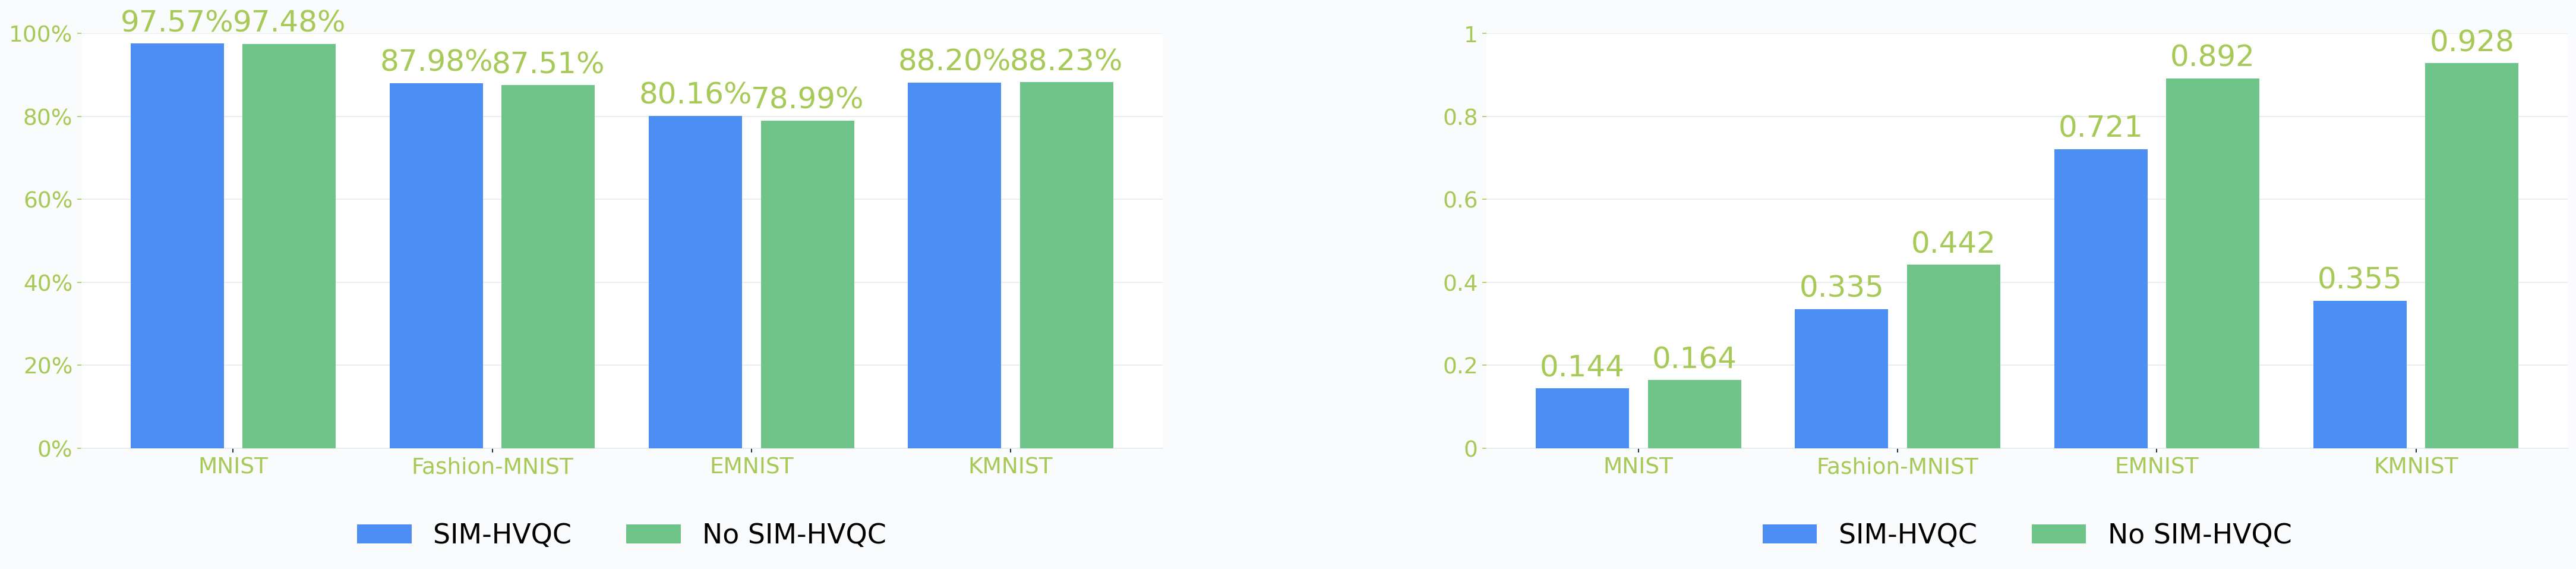

In [16]:
"""
SIM-HVQC vs. No SIM-HVQC — Accuracy & Loss comparison
Run this directly in a Kaggle notebook cell.

Only dependency: matplotlib (pre-installed on Kaggle).
"""


# ======================================================================
# FONT CONTROLS — change these to restyle the whole figure
# ======================================================================
FONT_FAMILY      = "DejaVu Sans"   # swap for any font available in the env
                                    # e.g. "Arial", "Helvetica", "Liberation Sans"
                                    # (see "custom font" note at bottom of file)
FONT_SIZE_TITLE      = 26
FONT_WEIGHT_TITLE    = "bold"

FONT_SIZE_SUBTITLE   = 18
FONT_WEIGHT_SUBTITLE = "normal"
FONT_STYLE_SUBTITLE  = "normal"

FONT_SIZE_AXIS       = 18
FONT_WEIGHT_AXIS     = "medium"

FONT_SIZE_LEGEND     = 22
FONT_WEIGHT_LEGEND   = "medium"

FONT_SIZE_VALUE_LABEL = 24   # numbers printed above each bar

# COLOR_TEXT_PRIMARY   = "#14181f"
# COLOR_TEXT_SECONDARY = "#6b7280"
# COLOR_GRID           = "#e8eaee"
# COLOR_BLUE           = "#4d8ef5"
# COLOR_GREEN          = "#6fc48a"
# COLOR_BG             = "#fafbfc"


COLOR_TEXT_PRIMARY   = "#f26e22"
COLOR_TEXT_SECONDARY = "#a7c957"
COLOR_GRID           = "#e8eaee"
COLOR_BLUE           = "#4d8ef5"
COLOR_GREEN          = "#6fc48a"
COLOR_BG             = "#fafbfc"

plt.rcParams["font.family"] = FONT_FAMILY
plt.rcParams["axes.edgecolor"] = COLOR_GRID
plt.rcParams["figure.facecolor"] = COLOR_BG
plt.rcParams["axes.facecolor"] = "white"

# ======================================================================
# DATA — computed averages from the run logs
# ======================================================================
labels = ["MNIST", "Fashion-MNIST", "EMNIST", "KMNIST"]

accuracy = {
    "SIM-HVQC":    [97.57, 87.98, 80.16, 88.20],
    "No SIM-HVQC": [97.48, 87.51, 78.99, 88.23],
}

loss = {
    "SIM-HVQC":    [0.144, 0.335, 0.721, 0.355],
    "No SIM-HVQC": [0.164, 0.442, 0.892, 0.928],
}

# ======================================================================
# PLOTTING HELPERS
# ======================================================================
def grouped_bar_chart(ax, data_dict, labels, title, subtitle, ylabel_fmt,
                       ymax=None, value_fmt="{:.2f}"):
    x = np.arange(len(labels))
    n_series = len(data_dict)
    bar_width = 0.36
    offsets = np.linspace(-bar_width * 0.6, bar_width * 0.6, n_series)

    colors = [COLOR_BLUE, COLOR_GREEN]

    for i, (name, values) in enumerate(data_dict.items()):
        bars = ax.bar(
            x + offsets[i], values, width=bar_width,
            label=name, color=colors[i % len(colors)],
            zorder=3, edgecolor="none"
        )
        # rounded-look edges: matplotlib has no native rounded bars,
        # so we fake it with a slight alpha + no border; for true rounded
        # corners use the patch trick in the optional block below.
        for b in bars:
            ax.text(
                b.get_x() + b.get_width() / 2,
                b.get_height() + (ymax or max(max(v) for v in data_dict.values())) * 0.015,
                value_fmt.format(b.get_height()),
                ha="center", va="bottom",
                fontsize=FONT_SIZE_VALUE_LABEL,
                color=COLOR_TEXT_SECONDARY
            )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=FONT_SIZE_AXIS,
                        fontweight=FONT_WEIGHT_AXIS, color=COLOR_TEXT_SECONDARY)

    ax.yaxis.set_major_formatter(plt.FuncFormatter(ylabel_fmt))
    ax.tick_params(axis="y", labelsize=FONT_SIZE_AXIS, colors=COLOR_TEXT_SECONDARY)

    if ymax:
        ax.set_ylim(0, ymax)

    ax.grid(axis="y", color=COLOR_GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(COLOR_GRID)

    ax.set_title(title, fontsize=FONT_SIZE_TITLE, fontweight=FONT_WEIGHT_TITLE,
                 color=COLOR_TEXT_PRIMARY, loc="left", pad=28)
    ax.text(0, 1.06, subtitle, transform=ax.transAxes,
            fontsize=FONT_SIZE_SUBTITLE, fontweight=FONT_WEIGHT_SUBTITLE,
            style=FONT_STYLE_SUBTITLE, color=COLOR_TEXT_SECONDARY, ha="left")

    ax.legend(
        loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2,
        frameon=False, fontsize=FONT_SIZE_LEGEND,
        prop={"weight": FONT_WEIGHT_LEGEND, "size": FONT_SIZE_LEGEND}
    )


# ======================================================================
# BUILD FIGURE
# ======================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(36, 7.5))
fig.subplots_adjust(wspace=0.3, bottom=0.2, top=0.82)

grouped_bar_chart(
    ax1, accuracy, labels,
    # title="Accuracy comparison: SIM-HVQC vs. no SIM-HVQC",
    # subtitle="Mean test accuracy across four benchmark datasets.",
    title="",
    subtitle="",
    ylabel_fmt=lambda v, pos: f"{v:.0f}%",
    ymax=100,
    value_fmt="{:.2f}%"
)

grouped_bar_chart(
    ax2, loss, labels,
    # title="Test loss comparison: SIM-HVQC vs. no SIM-HVQC",
    # subtitle="Mean test loss; lower values indicate better predictive performance.",
    title="",
    subtitle="",
    ylabel_fmt=lambda v, pos: f"{v:.2g}",
    ymax=1.0,
    value_fmt="{:.3f}"
)

plt.savefig("sim_hvqc_comparison.png", dpi=200, bbox_inches="tight", facecolor=COLOR_BG)
plt.show()

# ======================================================================
# OPTIONAL: using a custom font file (e.g. Inter, Helvetica Neue) on Kaggle
# ======================================================================
# Kaggle notebooks don't have most commercial fonts installed. To use one:
#
#   1. Upload the .ttf/.otf file as a Kaggle Dataset, or wget it from a
#      permitted source, e.g.:
#      !wget -O /kaggle/working/Inter-Regular.ttf <url-to-ttf>
#
#   2. Register it with matplotlib and set FONT_FAMILY:
#
#      custom_font = fm.FontProperties(fname="/kaggle/working/Inter-Regular.ttf")
#      fm.fontManager.addfont("/kaggle/working/Inter-Regular.ttf")
#      plt.rcParams["font.family"] = custom_font.get_name()
#
#   Then re-run the plotting cell — every title/axis/legend font above
#   will pick up the new family automatically.

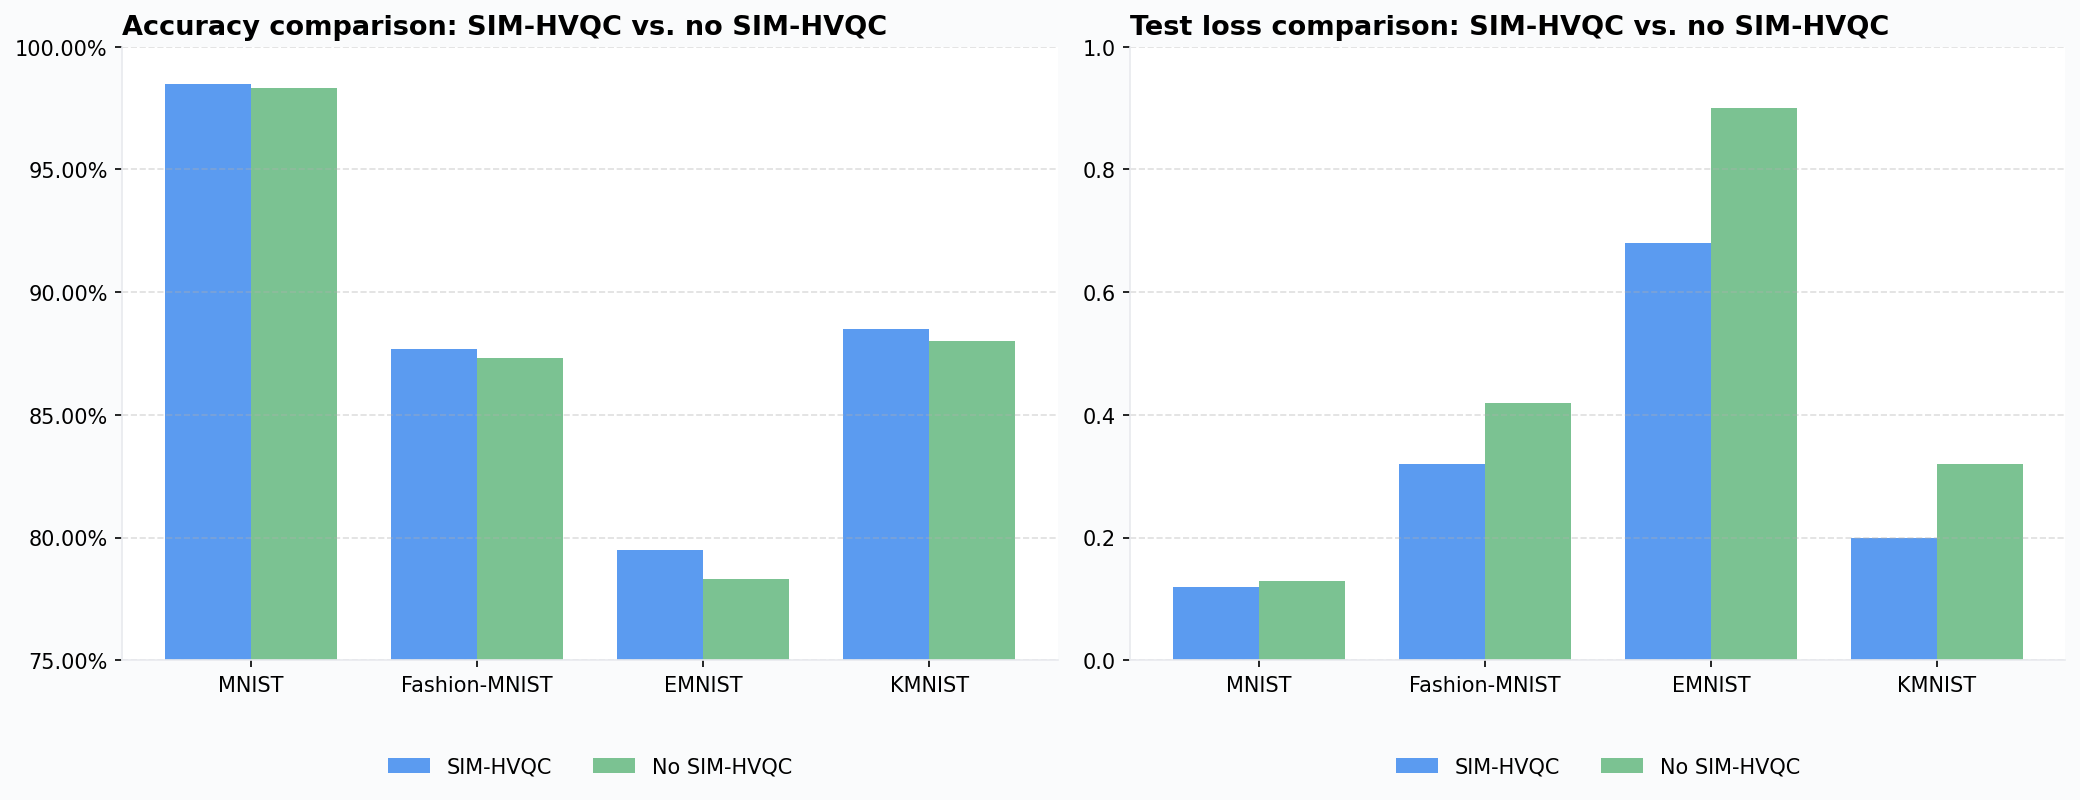

In [17]:

# ---- Replace these with your actual results ----
datasets = ['MNIST', 'Fashion-MNIST', 'EMNIST', 'KMNIST']

# Accuracy (%)
acc_sim_hvqc    = [98.5, 87.7, 79.5, 88.5]
acc_no_sim_hvqc = [98.3, 87.3, 78.3, 88.0]

# Test loss
loss_sim_hvqc    = [0.12, 0.32, 0.68, 0.20]
loss_no_sim_hvqc = [0.13, 0.42, 0.90, 0.32]
# --------------------------------------------------

color_sim = '#5B9BF0'      # blue
color_nosim = '#7BC292'    # green

x = np.arange(len(datasets))
width = 0.38

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# --- Accuracy plot ---
ax1 = axes[0]
ax1.bar(x - width/2, acc_sim_hvqc, width, label='SIM-HVQC', color=color_sim)
ax1.bar(x + width/2, acc_no_sim_hvqc, width, label='No SIM-HVQC', color=color_nosim)
ax1.set_title('Accuracy comparison: SIM-HVQC vs. no SIM-HVQC', fontsize=13, fontweight='bold', loc='left')
ax1.set_ylabel('')
ax1.set_ylim(75, 100)
ax1.set_xticks(x)
ax1.set_xticklabels(datasets)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2f}%'))
ax1.grid(axis='y', linestyle='--', alpha=0.4)
ax1.spines[['top', 'right']].set_visible(False)
ax1.legend(loc='lower center', bbox_to_anchor=(0.5, -0.22), ncol=2, frameon=False)

# --- Test loss plot ---
ax2 = axes[1]
ax2.bar(x - width/2, loss_sim_hvqc, width, label='SIM-HVQC', color=color_sim)
ax2.bar(x + width/2, loss_no_sim_hvqc, width, label='No SIM-HVQC', color=color_nosim)
ax2.set_title('Test loss comparison: SIM-HVQC vs. no SIM-HVQC', fontsize=13, fontweight='bold', loc='left')
ax2.set_ylim(0, 1)
ax2.set_xticks(x)
ax2.set_xticklabels(datasets)
ax2.grid(axis='y', linestyle='--', alpha=0.4)
ax2.spines[['top', 'right']].set_visible(False)
ax2.legend(loc='lower center', bbox_to_anchor=(0.5, -0.22), ncol=2, frameon=False)

plt.tight_layout()
plt.savefig('sim_hvqc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()